In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
f = lambda x: 3 * x ** 2 - 4 * x + 5
f(3)

20

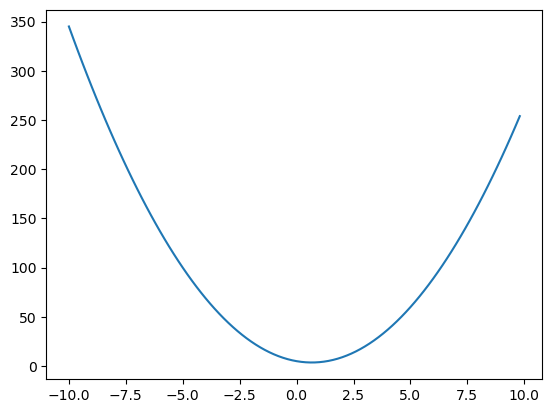

In [5]:
xs = np.arange(-10, 10, 0.2)
ys = f(xs)
plt.plot(xs, ys)

In [49]:
class Value:
    def __init__(self, data, children=(), op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(children)
        self._op = op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad = 1.0 * out.grad
            self.data = self.data + 0.2*self.grad
            other.grad = 1.0 * out.grad
            other.data = other.data + 0.2*other.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = other.data * out.grad
            self.data = self.data + 0.2*self.grad
            other.grad = self.data * out.grad
            other.data = other.data + 0.2*other.grad

        out._backward = _backward
        return out



In [65]:
a = Value(2.0, 'a')
b = Value(-3.0, 'b')
c = Value(10.0, 'c')
e = a * b;
e.label = 'e'
d = e + c;
d.label = 'd'
f = Value(-2.0, 'f')
l = d * f;
l.label = 'l'
l.grad = 1.0